In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from itertools import permutations,combinations

In [70]:
with open("../../Data/disease_to_snomed_id.json", "r") as file:
    disease_to_snomed_id = json.load(file)

In [71]:
LIST_OF_DISEASES = list(disease_to_snomed_id.keys())

In [72]:
LIST_OF_DISEASES = ['BIPOLAR',
 'SCHIZOPHRENIA',
 'LEUKEMIA',
 'BREASTCANCER']

In [73]:
def jaccard(A, B):
    """
    Compute Jaccard similarity between two iterables.
    """
    A = set(A)
    B = set(B)

    if not A and not B:
        return 0.0

    return len(A & B) / len(A | B)

In [74]:
def jaccard_matrix(communities_left, communities_right):
    """
    Compute Jaccard similarity matrix between two lists of communities.

    Rows correspond to communities_left,
    columns correspond to communities_right.
    """
    J = np.zeros((len(communities_left), len(communities_right)), dtype=float)

    for i, A in enumerate(communities_left):
        for j, B in enumerate(communities_right):
            J[i, j] = jaccard(A, B)

    return J

In [75]:
def plot_heatmap(M, row_labels=None, col_labels=None,
                 cmap="viridis", vmin=None, vmax=None, save_path=None):
    """
    Plot a heatmap for a 2D matrix, with optional row/column labels,
    and show the value in each cell.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    M = np.asarray(M)

    plt.figure()
    im = plt.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    plt.colorbar(im)

    # Optional labels
    if row_labels is not None:
        plt.yticks(range(len(row_labels)), row_labels)
    else:
        plt.yticks([])

    if col_labels is not None:
        plt.xticks(range(len(col_labels)), col_labels, rotation=90)
    else:
        plt.xticks([])

    # ---- ADD CELL VALUE ANNOTATIONS ----
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            plt.text(
                j, i,
                f"{M[i, j]:.2f}",          # format here
                ha="center",
                va="center",
                color="white"
            )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()


In [76]:
def community_jaccard_matrix_selected(d1,d2, show_plot = True, selected = True):
    if (selected):
        with open(f"../output/{d1}/leiden_results/result_communities_HGNC_selected.pkl", "rb") as f:
            communities_selected1 = pickle.load(f)
        with open(f"../output/{d2}/leiden_results/result_communities_HGNC_selected.pkl", "rb") as f:
            communities_selected2 = pickle.load(f)
    else:
        with open(f"../output/{d1}/leiden_results/result_communities_HGNC.pkl", "rb") as f:
            communities_selected1 = pickle.load(f)
        with open(f"../output/{d2}/leiden_results/result_communities_HGNC.pkl", "rb") as f:
            communities_selected2 = pickle.load(f)
            
    with open(f"../output/{d1}/important_comm_idx.pkl", "rb") as f:
        top_keys1 = pickle.load(f)
    with open(f"../output/{d2}/important_comm_idx.pkl", "rb") as f:
        top_keys2 = pickle.load(f)    
            
    with open(f"../output/{d1}/comm_dgidb_gene_count.json", "rb") as f:
        dgidb_gene_count1 = json.load(f)
    dgidb_gene_count1 = {int(k): v for k, v in dgidb_gene_count1.items()}
    with open(f"../output/{d2}/comm_dgidb_gene_count.json", "rb") as f:
        dgidb_gene_count2 = json.load(f)
    dgidb_gene_count2 = {int(k): v for k, v in dgidb_gene_count2.items()}

    # construct sim matrix
    print(top_keys1, top_keys2)
    print(len(communities_selected1), len(communities_selected2))
    communities_selected_dgidb1 = [communities_selected1[i] for i in top_keys1]
    communities_selected_dgidb2 = [communities_selected2[i] for i in top_keys2]
    J = jaccard_matrix(communities_selected_dgidb1,communities_selected_dgidb2)
    
    if (show_plot):
        plot_heatmap(
            J, 
            row_labels=top_keys1,
            col_labels=top_keys2,
            vmin=0, vmax=1
        )
        
    return J
        
    

[1, 9, 6, 8, 0, 5] [4, 7, 2]
10 10


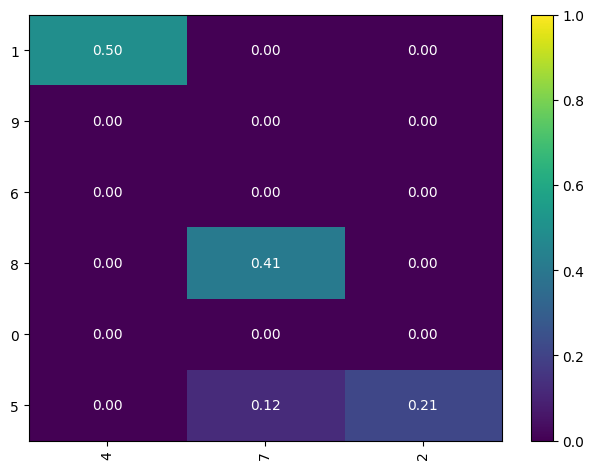

In [85]:
Q = community_jaccard_matrix_selected("BIPOLAR","LEUKEMIA", show_plot = True)

In [78]:
# Mean-max jaccard score
jaccard_scores = []
l = len(LIST_OF_DISEASES)
dsm = np.zeros([l,l])
np.fill_diagonal(dsm, 1)
for i,j in combinations(range(l), 2):
    d1,d2 = LIST_OF_DISEASES[i],LIST_OF_DISEASES[j]
    J = community_jaccard_matrix_selected(d1,d2,show_plot = False, selected = True)
    mean_best_jaccard = (J.max(axis=1).sum() + J.max(axis=0).sum()) / (J.shape[0] + J.shape[1])
    dsm[i,j] = mean_best_jaccard
    jaccard_scores.append((mean_best_jaccard,i,j))
    
# symmetrize
dsm = dsm + dsm.T
np.fill_diagonal(dsm, 1)

print(dsm)

[1, 9, 6, 8, 0, 5] [1, 10, 2, 8]
10 12
[1, 9, 6, 8, 0, 5] [4, 7, 2]
10 10
[1, 9, 6, 8, 0, 5] [1, 7, 4, 3, 5]
10 9
[1, 10, 2, 8] [4, 7, 2]
12 10
[1, 10, 2, 8] [1, 7, 4, 3, 5]
12 9
[4, 7, 2] [1, 7, 4, 3, 5]
10 9
[[1.         0.50698507 0.24792226 0.29376814]
 [0.50698507 1.         0.1385758  0.19949588]
 [0.24792226 0.1385758  1.         0.46188352]
 [0.29376814 0.19949588 0.46188352 1.        ]]


In [79]:
# Max jaccard score
jaccard_scores = []
l = len(LIST_OF_DISEASES)
dsm_max = np.zeros([l,l])
np.fill_diagonal(dsm_max, 1)
for i,j in combinations(range(l), 2):
    d1,d2 = LIST_OF_DISEASES[i],LIST_OF_DISEASES[j]
    J = community_jaccard_matrix_selected(d1,d2,show_plot = False, selected = True)
    best_jaccard = J.max()
    dsm_max[i,j] = best_jaccard
    jaccard_scores.append((mean_best_jaccard,i,j))
    
# symmetrize
dsm_max = dsm_max + dsm_max.T
np.fill_diagonal(dsm_max, 1)

print(dsm_max)

[1, 9, 6, 8, 0, 5] [1, 10, 2, 8]
10 12
[1, 9, 6, 8, 0, 5] [4, 7, 2]
10 10
[1, 9, 6, 8, 0, 5] [1, 7, 4, 3, 5]
10 9
[1, 10, 2, 8] [4, 7, 2]
12 10
[1, 10, 2, 8] [1, 7, 4, 3, 5]
12 9
[4, 7, 2] [1, 7, 4, 3, 5]
10 9
[[1.         0.94221106 0.49537323 0.51941748]
 [0.94221106 1.         0.48501529 0.50902527]
 [0.49537323 0.48501529 1.         0.65594855]
 [0.51941748 0.50902527 0.65594855 1.        ]]


In [80]:
jaccard_scores = sorted(jaccard_scores, key = lambda x: x[0], reverse = True)
jaccard_scores

[(0.4618835219757128, 0, 1),
 (0.4618835219757128, 0, 2),
 (0.4618835219757128, 0, 3),
 (0.4618835219757128, 1, 2),
 (0.4618835219757128, 1, 3),
 (0.4618835219757128, 2, 3)]

In [81]:
jaccard_scores_disease = [(LIST_OF_DISEASES[i],LIST_OF_DISEASES[j],s) for s,i,j in jaccard_scores]
jaccard_scores_disease

[('BIPOLAR', 'SCHIZOPHRENIA', 0.4618835219757128),
 ('BIPOLAR', 'LEUKEMIA', 0.4618835219757128),
 ('BIPOLAR', 'BREASTCANCER', 0.4618835219757128),
 ('SCHIZOPHRENIA', 'LEUKEMIA', 0.4618835219757128),
 ('SCHIZOPHRENIA', 'BREASTCANCER', 0.4618835219757128),
 ('LEUKEMIA', 'BREASTCANCER', 0.4618835219757128)]

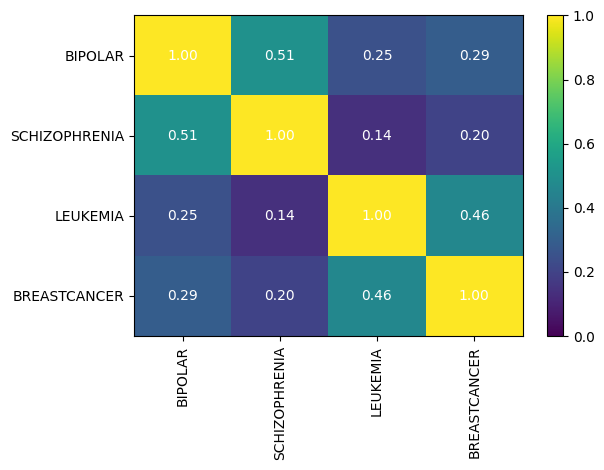

In [82]:
plot_heatmap(
    dsm, 
    row_labels=LIST_OF_DISEASES,
    col_labels=LIST_OF_DISEASES,
    vmin=0, 
    vmax=1,
    save_path= "../../Graphs/disease_similarity_heatmap.png"
)


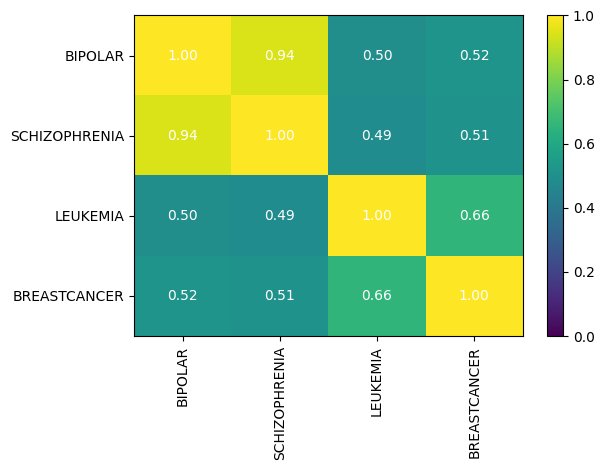

In [83]:
plot_heatmap(
    dsm_max, 
    row_labels=LIST_OF_DISEASES,
    col_labels=LIST_OF_DISEASES,
    vmin=0, 
    vmax=1,
    save_path= "../../Graphs/disease_similarity_heatmap_max.png"
)
